# Reproducing a published trans-omic study

A method earns its place only if it answers questions a per-layer analysis
cannot, *and gets the answers right*. This notebook tests both against
[Uematsu *et al.*, *iScience* 25(2):103787, 2022](https://doi.org/10.1016/j.isci.2022.103787):
liver transcriptome, proteome and metabolome in the same animals, wild-type
and leptin-deficient obese (ob/ob), fasted and 4 h after oral glucose.

The data is the Kuroda laboratory's shared liver cohort, released with their
OMELET code under GPL-3.0, which is also why the claims of Kokaji *et al.*
(*Sci. Signal.* 13:eaaz1236, 2020) can be scored on it. TransNet is
MIT-licensed, so the files are downloaded at run time and never committed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transnet import (
    cross_layer_connectivity,
    downstream_influence,
    expression_concordance,
    layer_coverage,
    regulation_axis_summary,
    transcription_factor_activity,
    transomic_hubs,
    map_omics_to_network,
    metabolite_regulatory_roles,
    reaction_regulation_table,
    regulatory_role_enrichment,
    responsive_subnetwork,
    path_consistency_summary,
    trace_regulatory_paths,
)
from transnet.analysis import path_verdicts, versus_chance
from transnet.datasets import (
    DATA_DIR,
    UEMATSU_CONTRASTS,
    UEMATSU_LOG2FC,
    UEMATSU_METABOLITE_IDS,
    fetch_uematsu_panel,
    load_uematsu_panel,
    uematsu_contrast,
    uematsu_panel_network,
)

OUT = DATA_DIR / "published_results" / "obese_liver"
OUT.mkdir(parents=True, exist_ok=True)
QVALUE = 0.1                      # the threshold the Kuroda laboratory uses

fetch_uematsu_panel()
graph, id_map = uematsu_panel_network()
print(f"panel neighbourhood: {graph.number_of_nodes()} molecules, "
      f"{graph.number_of_edges()} relationships")

panel neighbourhood: 221 molecules, 387 relationships


In [2]:
connectivity = cross_layer_connectivity(graph)
print(f"{connectivity['cross_layer_fraction']:.0%} of the panel's edges cross layers")
connectivity["matrix"]

100% of the panel's edges cross layers


,Transcriptome,Proteome,Reactions,Metabolome
Transcriptome,0,19,0,0
Proteome,0,0,66,0
Reactions,0,0,0,101
Metabolome,0,0,201,0


In [3]:
panels = {layer: load_uematsu_panel(layer) for layer in
          ("Transcriptome", "Proteome", "Metabolome")}
pd.DataFrame({layer: {"features": values.shape[0], "samples": values.shape[1]}
              for layer, (values, _) in panels.items()}).T

,features,samples
Transcriptome,19,47
Proteome,19,47
Metabolome,32,47


## What a per-layer analysis can say

Three lists of changed molecules, and the overlap between two of them.
Molecules are called changed at 1.5-fold and q <= 0.1, the definition the
authors use.

In [4]:
LABEL, REFERENCE, TEST = UEMATSU_CONTRASTS[2]     # ob/ob vs WT, fasting
tables = {layer: uematsu_contrast(values, design, REFERENCE, TEST)
          for layer, (values, design) in panels.items()}

changed = {layer: table[(table["padj"] <= QVALUE)
                        & (table["log2FC"].abs() >= UEMATSU_LOG2FC)]
           for layer, table in tables.items()}
print(LABEL)
for layer, table in changed.items():
    print(f"  {layer:<15}{len(table):>3} changed of {len(tables[layer]):>3} measured")

shared = set(changed["Transcriptome"]["feature"]) & set(changed["Proteome"]["feature"])
print(f"  shared between transcript and protein lists: {len(shared)}")

ob/ob vs WT, fasting
  Transcriptome    3 changed of  19 measured
  Proteome         8 changed of  17 measured
  Metabolome       6 changed of  32 measured
  shared between transcript and protein lists: 2


/Users/krv114/Documents/GitHub/transnet/transnet/datasets.py:694: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  pvalue = stats.ttest_ind(b, a, axis=1, equal_var=False, nan_policy="omit").pvalue


That is the whole of it. Which reactions are affected, through which
mechanism, and whether the layers agree are not answerable from those lists
They are what the published paper asks.

## Onto the network

In [5]:
extra = {name: ids for name, ids in UEMATSU_METABOLITE_IDS.items() if len(ids) > 1}

report = map_omics_to_network(
    graph, tables, id_column="feature", log2fc_column="log2FC", qvalue_column="padj",
    se_column="se", id_map=id_map, qvalue_threshold=QVALUE,
    log2fc_threshold=UEMATSU_LOG2FC,
)
# A mass spectrometer measures a sugar phosphate as one pool while KEGG names
# its anomers separately, so one measurement is attached to every form a
# reaction uses.
for name, ids in extra.items():
    row = tables["Metabolome"][tables["Metabolome"]["feature"] == name]
    if row.empty:
        continue
    for identifier in ids[1:]:
        if identifier in graph:
            graph.nodes[identifier].update(
                log2fc=float(row["log2FC"].iloc[0]), qvalue=float(row["padj"].iloc[0]),
                measured=True,
                regulated=int(np.sign(row["log2FC"].iloc[0]))
                if (row["padj"].iloc[0] <= QVALUE
                    and abs(row["log2FC"].iloc[0]) >= UEMATSU_LOG2FC) else 0,
            )
report.per_layer

,layer,n_supplied,n_matched,match_fraction,n_layer_nodes,layer_covered,n_up,n_down,n_undirected,note
0,Transcriptome,19,19,1.000,19,1.000000,2,1,0,
1,Proteome,17,17,1.000,19,0.894737,7,1,0,
2,Metabolome,32,28,0.875,125,0.224000,4,1,0,


## What the network says

In [6]:
regulation = reaction_regulation_table(graph)
regulated = regulation[(regulation["gene_axis"] != 0) | (regulation["metabolite_axis"] != 0)]
enzyme_only = regulated[(regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] == 0)]
metabolite_only = regulated[(regulated["gene_axis"] == 0) & (regulated["metabolite_axis"] != 0)]
both = regulated[(regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] != 0)]

print(f"{len(regulated)} of {len(regulation)} reactions regulated: {len(enzyme_only)} through "
      f"enzyme amount only, {len(metabolite_only)} through metabolites only, {len(both)} through both")
print(f"{int(regulated['controversial'].sum())} controversial")
regulated.head(8)[["reaction", "name", "gene_axis", "metabolite_axis", "gene_axis_evidence"]]

49 of 58 reactions regulated: 31 through enzyme amount only, 5 through metabolites only, 13 through both
9 controversial


,reaction,name,gene_axis,metabolite_axis,gene_axis_evidence
0,R00200,ATP:pyruvate 2-O-phosphotransferase; ATP + Pyr...,1,-1,protein
2,R00258,L-alanine:2-oxoglutarate aminotransferase; L-A...,0,1,None
6,R00430,GTP:pyruvate 2-O-phosphotransferase; GTP + Pyr...,1,-1,protein
7,R00431,GTP:oxaloacetate carboxy-lyase (adding GTP;pho...,-1,0,protein
8,R00572,CTP:pyruvate 2-O-phosphotransferase; CTP + Pyr...,1,-1,protein
9,R00658,2-phospho-D-glycerate hydro-lyase (phosphoenol...,1,0,protein
10,R00659,UTP:pyruvate 2-O-phosphotransferase; UTP + Pyr...,1,-1,protein
11,R00703,(S)-lactate:NAD+ oxidoreductase; (S)-Lactate +...,1,-1,protein


In [7]:
layer_coverage(graph)

,layer,n_nodes,n_measured,measured_fraction,n_responsive,n_regulated,n_up,n_down,mean_degree
0,Transcriptome,19,19,1.000000,3,3,2,1,1.000000
1,Proteome,19,17,0.894737,8,8,7,1,4.473684
2,Reactions,58,0,0.000000,0,0,0,0,6.344828
3,Metabolome,125,32,0.256000,7,7,6,1,2.416000


## Per-pathway balance

In [8]:
regulation_axis_summary(regulation)

,pathway,n_reactions,gene_activated,gene_inhibited,metabolite_activated,metabolite_inhibited,n_controversial,fraction_controversial,fraction_gene_driven,fraction_metabolite_driven
0,all,49,41,3,7,11,9,0.183673,0.897959,0.367347


## Which factors drive the responsive genes, and which molecules join layers

In [9]:
factors = transcription_factor_activity(graph, min_targets=3)
implicated = factors[factors["q_value"] <= 0.05] if not factors.empty else factors
print(f"{len(implicated)} of {len(factors)} transcription factors implicated "
      f"-- a 19-gene panel carries few targets, so this is a coverage limit")

hubs = transomic_hubs(responsive_subnetwork(graph), top_percent=10)
hubs.head(8)[["name", "layer", "cross_layer_degree", "n_layers_touched"]]

No transcriptional_regulation edges reach a measured gene; transcription factor activity cannot be inferred


0 of 0 transcription factors implicated -- a 19-gene panel carries few targets, so this is a coverage limit


,name,layer,cross_layer_degree,n_layers_touched
0,Pyruvate kinase PKLR (EC 2.7.1.40) (L-PK) (Pyr...,Proteome,9,2
1,L-Alanine; L-2-Aminopropionic acid; L-alpha-Al...,Metabolome,8,1
2,Glucose-6-phosphate isomerase (GPI) (EC 5.3.1....,Proteome,5,1
3,alpha-D-Glucose 6-phosphate,Metabolome,3,1
4,beta-D-Glucose 6-phosphate,Metabolome,2,1
5,L-lactate dehydrogenase A chain (LDH-A) (EC 1....,Proteome,1,1
6,Gpd1,Transcriptome,1,1
7,ATP; Adenosine 5'-triphosphate,Metabolome,1,1


## Does the upper hierarchy predict the metabolites?

In [10]:
seeds = {n: float(d["log2fc"]) for n, d in graph.nodes(data=True)
         if d.get("layer") in ("Transcriptome", "Proteome")
         and d.get("regulated") and d.get("log2fc") is not None}
influence = downstream_influence(graph, seeds, target_layer="Metabolome")
measured = influence[influence["observed"].fillna(0) != 0] if "observed" in influence else influence
if not measured.empty and "agrees" in measured:
    agree = int(measured["agrees"].astype("boolean").fillna(False).sum())
    print(f"{agree} of {len(measured)} changed metabolites predicted correctly: "
          f"{versus_chance(agree, len(measured))}")
measured.head(10)

1 of 1 changed metabolites predicted correctly: 100%, no better than the 50% expected by chance (binomial p = 1)


,node,layer,name,score,abs_score,predicted_direction,observed,agrees
29,C01172,Metabolome,beta-D-Glucose 6-phosphate,0.006213,0.006213,1,1,True


Path tracing asks the same question the other way round: rather than
propagating outwards, it walks signed routes from each changed gene or
protein to each changed metabolite and asks whether the sign along the route
matches the direction observed.

In [11]:
paths = trace_regulatory_paths(graph, target_layer="Metabolome", max_length=4)
summary = path_consistency_summary(paths)
if not summary.empty:
    agree = int(summary["agrees"].astype("boolean").fillna(False).sum())
    print(f"{len(paths)} signed paths to {len(summary)} changed metabolites; "
          f"{agree} predicted in the right direction: "
          f"{versus_chance(agree, len(summary))}")
else:
    print(f"{len(paths)} signed paths, none reaching a metabolite that changed")
summary.head(10)

1 signed paths to 1 changed metabolites; 1 predicted in the right direction: 100%, no better than the 50% expected by chance (binomial p = 1)


,target,observed,n_paths,n_fully_signed,n_consistent,fraction_consistent,predicted,agrees,shortest_consistent_path
0,C01172,1,1,1,1,1.0,1,True,P06745 -> R02739 -> C01172


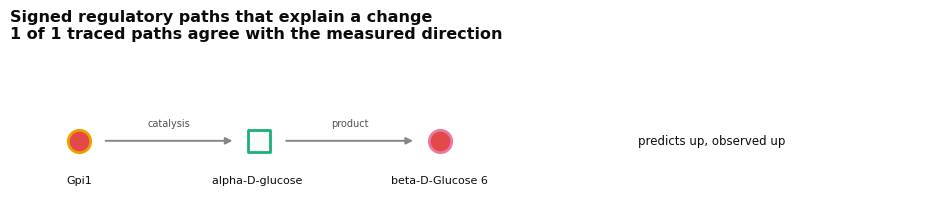

In [12]:
from transnet.visualization import plot_regulatory_paths

paths_figure = plot_regulatory_paths(paths, graph, top_n=8)
plt.show()

## Are the layers sample-paired?

A joint factor model needs each column to be the same animal in every file.
The design rows line up and the authors describe the layers as measured in
the same individuals, but that is a claim the data can check: within a group,
transcript and protein should agree better as listed than under a shuffled
pairing.

In [13]:
from transnet.analysis.factors import (
    factor_design_association,
    factor_network_coherence,
    factor_network_propagation,
    fit_factors,
    pairing_robustness,
    sample_pairing_check,
)

transcript_values, transcript_design = panels["Transcriptome"]
protein_values, _ = panels["Proteome"]
genes = sorted(set(transcript_values.index) & set(protein_values.index))
groups = (transcript_design["genotype"] + " " + transcript_design["minutes"]).astype(str)
groups.index = transcript_values.columns

pairing = sample_pairing_check(transcript_values.loc[genes].T, protein_values.loc[genes].T,
                               groups, n_permutations=500)
print(f"agreement as listed {pairing['observed']:.3f}, under shuffled pairings "
      f"{pairing['null_mean']:.3f} (permutation p = {pairing['p_value']:.2f}) -> "
      f"{'paired' if pairing['paired'] else 'pairing not confirmed'}")

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


agreement as listed 0.066, under shuffled pairings -0.004 (permutation p = 0.10) -> pairing not confirmed


With 17 genes in both layers the check has little power: the agreement leans
the right way but does not reach significance, so the pairing is neither
confirmed nor refuted. The factor model is fitted and then *tested for whether
that matters*: a factor carried by genotype or glucose -- whose labels are
certain -- keeps its cross-layer agreement however the mice within a group
are paired, and is interpretable either way. One living in mouse-to-mouse
variation is not read further until the pairing is confirmed.

In [14]:
import numpy as np

matrices = {}
for layer, (values, _) in panels.items():
    frame = values.T.apply(pd.to_numeric, errors="coerce")
    frame = np.log2(frame.clip(lower=0) + (1.0 if np.nanmax(frame.to_numpy()) > 50 else 1e-3))
    matrices[layer] = frame.loc[:, frame.notna().mean() >= 0.8]
design = transcript_design.assign(sample=transcript_values.columns).set_index("sample")[
    ["genotype", "minutes"]].astype(str)

factorisation = fit_factors(matrices, n_components=4)
association = factor_design_association(factorisation.factors_, design, ["genotype", "minutes"])
robustness = pairing_robustness(factorisation, groups, n_shuffles=200)
factor_ids = {"Transcriptome": id_map["Transcriptome"], "Proteome": id_map["Proteome"],
              "Metabolome": id_map["Metabolome"]}
coherence = factor_network_coherence(graph, factorisation.loadings_, id_maps=factor_ids,
                                     top_n=10, n_permutations=500)
propagation = factor_network_propagation(graph, factorisation.loadings_, id_maps=factor_ids,
                                         top_n=10, n_permutations=200)

(association.pivot(index="factor", columns="term", values="partial_eta_squared")
 .join(robustness.set_index("factor")[["agreement", "retained", "verdict"]])
 .join(coherence["table"].set_index("factor")[["fold_enrichment"]]
       .rename(columns={"fold_enrichment": "direct links vs chance"}))
 .join(propagation["table"].set_index("factor")[["overlap", "null_overlap", "q_value"]]
       .rename(columns={"q_value": "overlap q"}))
 .round(3))

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


,genotype,genotype x minutes,minutes,agreement,retained,verdict,direct links vs chance,overlap,null_overlap,overlap q
factor,,,,,,,,,,
Factor1,0.728,0.158,0.430,0.736,0.962,between-group,1.182,0.395,0.348,0.418
Factor2,0.455,0.182,0.251,0.271,0.671,single-layer,0.875,0.406,0.396,0.557
Factor3,0.678,0.295,0.235,-0.040,NaN,single-layer,0.874,0.298,0.350,0.811
Factor4,0.798,0.325,0.269,0.736,0.961,between-group,1.241,0.433,0.367,0.418


Only a factor marked ``between-group`` is read further here: its layers agree
whatever the pairing, so it is carried by genotype or glucose rather than by
how the columns of three files happen to line up.

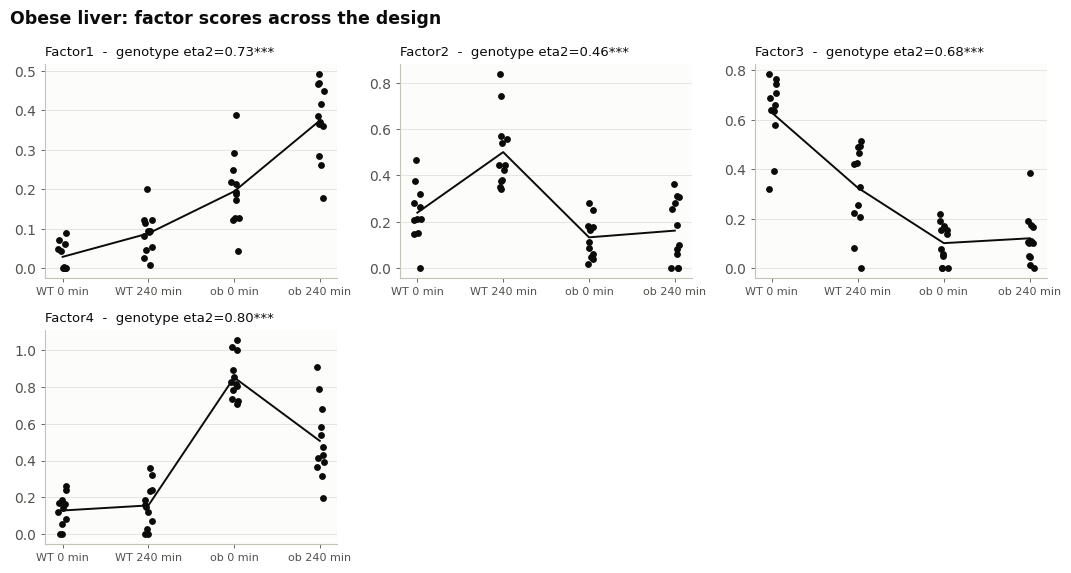

In [15]:
from transnet.visualization import plot_factor_network, plot_factor_scores

FACTOR_OUT = OUT / "factors"
FACTOR_OUT.mkdir(parents=True, exist_ok=True)

design_plot = design.assign(group=design["genotype"] + " " + design["minutes"] + " min")
plot_factor_scores(factorisation.factors_, design_plot, x="group",
                   x_order=["WT 0 min", "WT 240 min", "ob 0 min", "ob 240 min"],
                   association=association,
                   title="Obese liver: factor scores across the design"
                   ).savefig(FACTOR_OUT / "factor_scores.png", dpi=150, bbox_inches="tight")
plt.show()

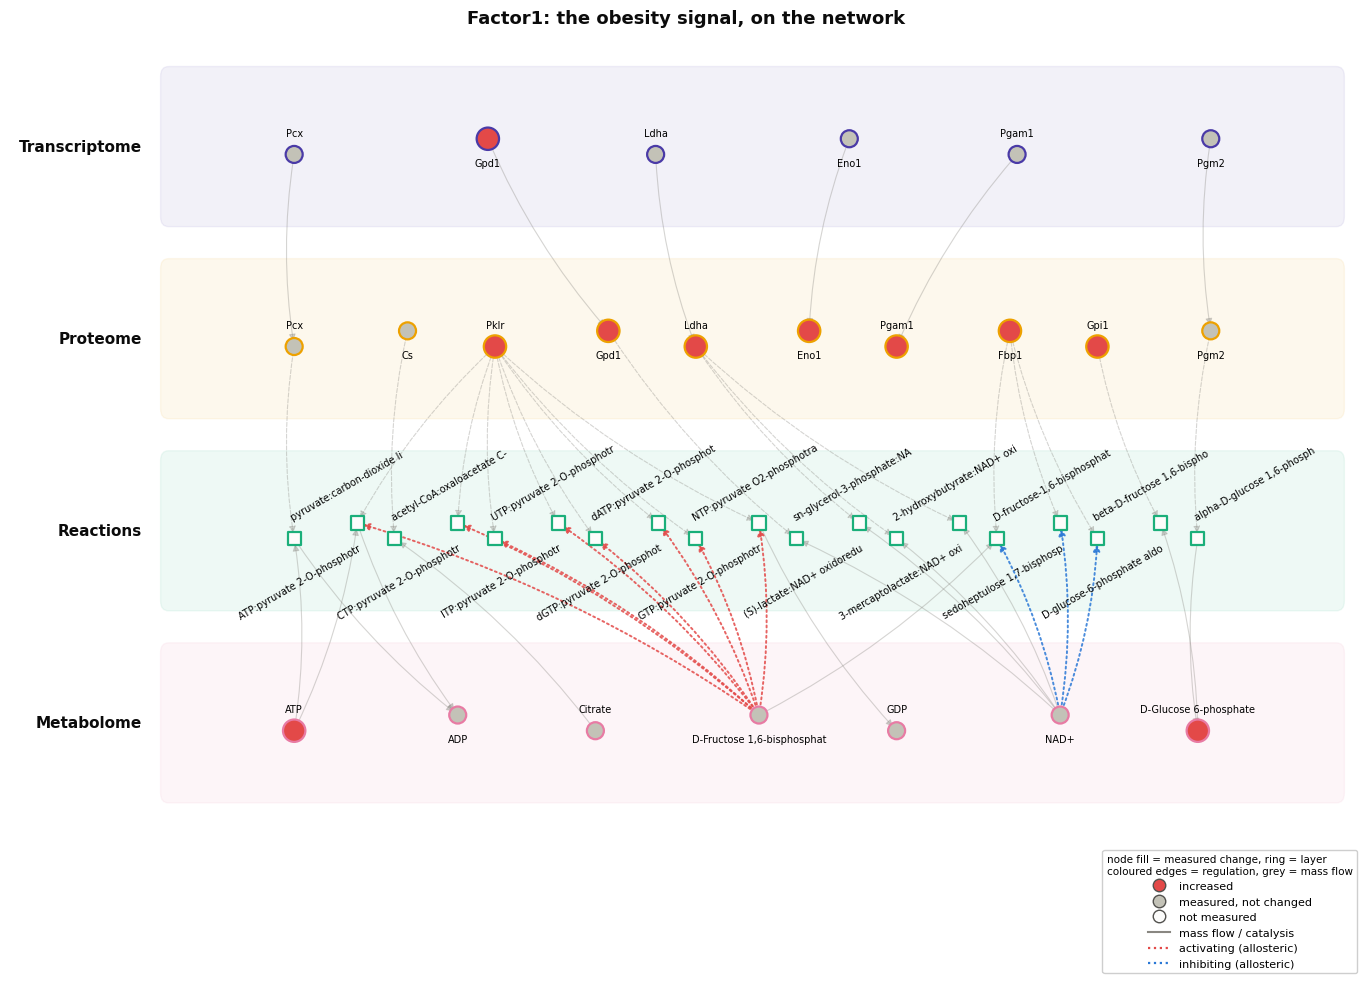

Factor1: where its layers meet
                                            name      layer  enrichment
                                         Citrate Metabolome         5.5
                           D-Glucose 6-phosphate Metabolome         4.9
                     D-Fructose 1,6-bisphosphate Metabolome         3.4
               alpha-D-glucose 1,6-phosphomutase  Reactions         3.1
acetyl-CoA:oxaloacetate C-acetyltransferase (thi  Reactions         2.8
                                        Fumarate Metabolome         2.7
   D-glucose-6-phosphate aldose-ketose-isomerase  Reactions         2.5
                                            Gpd1   Proteome         2.2


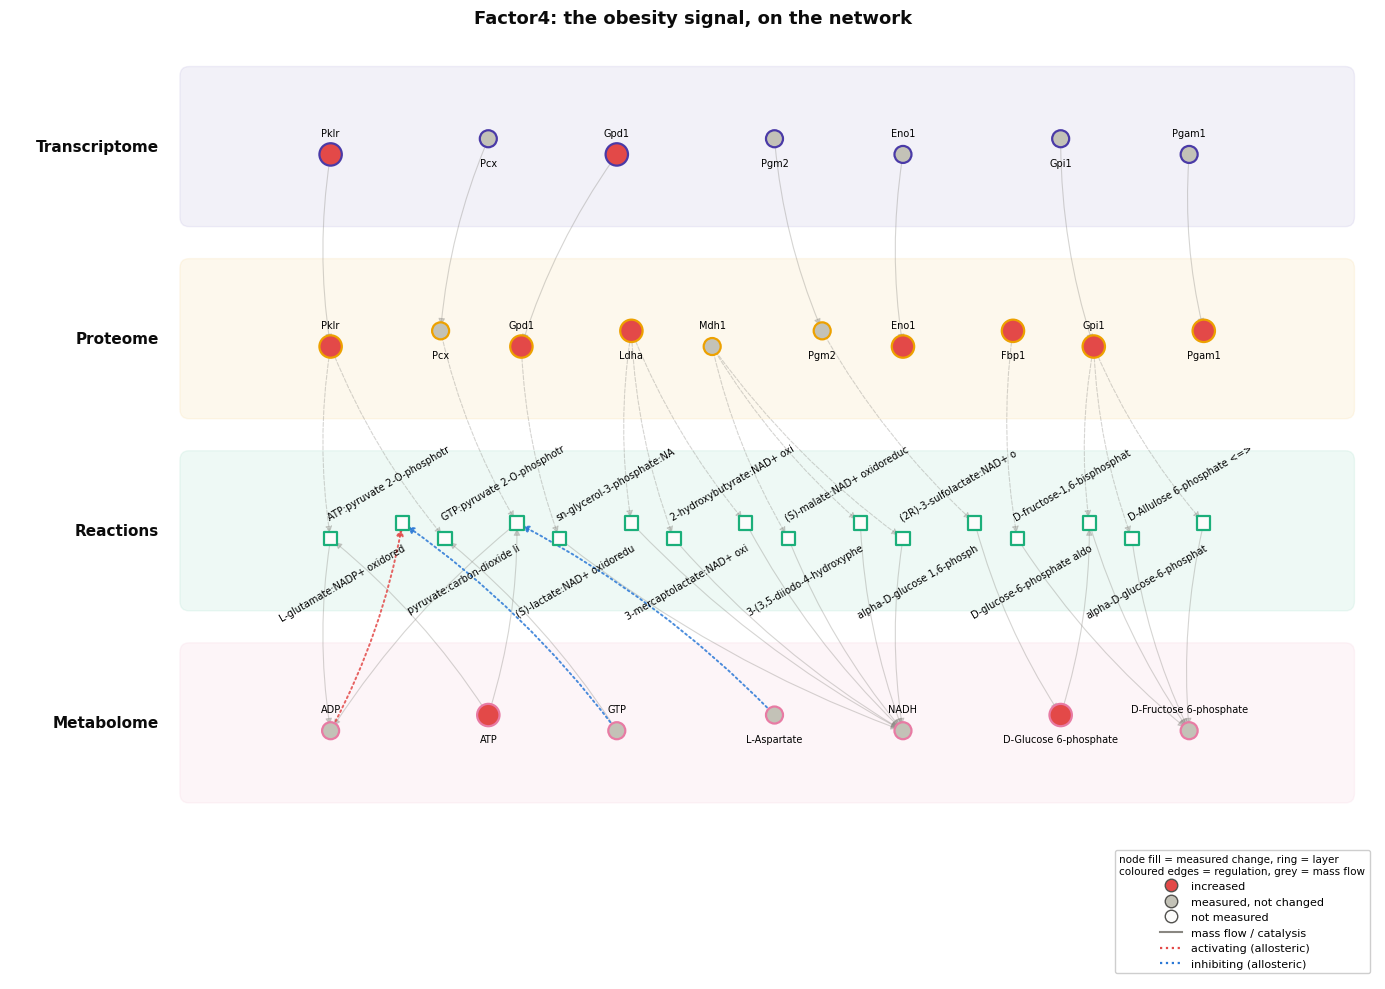

Factor4: where its layers meet
                                         name         layer  enrichment
                       D-Fructose 6-phosphate    Metabolome         4.8
                        D-Glucose 6-phosphate    Metabolome         4.6
                                  L-Glutamate    Metabolome         3.4
                                  L-Aspartate    Metabolome         3.3
D-glucose-6-phosphate aldose-ketose-isomerase     Reactions         3.3
                                    Succinate    Metabolome         3.2
            alpha-D-glucose 1,6-phosphomutase     Reactions         3.2
                                         Pklr Transcriptome         2.5


In [16]:
robust_factors = robustness.loc[robustness["verdict"] == "between-group", "factor"].tolist()
for factor in robust_factors:
    linked = coherence["nodes"].get(factor, [])
    figure = plot_factor_network(graph, factorisation.loadings_, factor,
                                 id_maps=factor_ids, nodes=linked or None,
                                 top_n=10, max_nodes=60,
                                 title=f"{factor}: the obesity signal, on the network")
    figure.savefig(FACTOR_OUT / f"network_{factor}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{factor}: where its layers meet")
    print(propagation["top_nodes"][factor].head(8)[["name", "layer", "enrichment"]]
          .round(1).to_string(index=False))

## Are the protein changes transcriptional?

The paper's central claim is that obese liver is rewired through enzyme
amount, and specifically through increased *transcripts*. The threshold-free
test, protein change minus transcript change with standard errors, is
what decides that without depending on where the cutoff sits.

In [17]:
concordance = expression_concordance(graph)
counts = concordance["counts"]
print(f"{counts['concordant']} concordant, {counts['protein_only']} protein-only, "
      f"{counts['discordant']} against their transcript")
print(f"{counts.get('protein_beyond_transcript')} proteins moved significantly further than "
      f"their transcript, of {counts.get('tested_difference')} testable")

table = concordance["table"]
table[table.get("protein_beyond_transcript", False) == True][
    [c for c in ("name", "gene_log2fc", "protein_log2fc", "difference", "difference_q")
     if c in table.columns]
]

2 concordant, 6 protein-only, 0 against their transcript
4 proteins moved significantly further than their transcript, of 17 testable


,name,gene_log2fc,protein_log2fc,difference,difference_q
2,Ldha,0.303369,0.782984,0.479615,6.833318e-05
3,Eno1,0.404367,0.960049,0.555681,2.241710e-09
4,Gpi1,0.196467,1.203885,1.007418,9.067268e-14
5,Fbp1,-0.140187,1.196494,1.336681,2.338090e-56


## The wiring behind the controversial calls

The panel is central carbon metabolism, where product inhibition is the
textbook mechanism. Finding it from the wiring rather than assuming it is
what lets a controversial reaction be explained instead of just flagged.

In [18]:
from transnet import convergence_significance, regulatory_motifs, structural_vulnerability

motifs = regulatory_motifs(graph)
print(motifs["counts"])
motifs["motifs"][["motif", "reaction_name", "metabolite_name", "enzyme", "sign_product"]].head(10)

{}


,motif,reaction_name,metabolite_name,enzyme,sign_product


In [19]:
convergence = convergence_significance(graph, n_randomisations=500)
print(f"{convergence['observed']} reactions carry both axes; the shuffled null gives "
      f"{convergence['null_mean']:.1f} (z = {convergence['z']:+.1f}, "
      f"p = {convergence['p_value']:.3g})")

structural_vulnerability(responsive_subnetwork(graph), top_n=8)

14 reactions carry both axes; the shuffled null gives 6.3 (z = +1.9, p = 0.0499)


""


## The published claims, scored

Each claim is given the number from this analysis that bears on it, and a
verdict. Two of them come from genome-wide, multi-timepoint studies: a
19-gene panel at one timepoint is the wrong instrument, and the verdict says
"not reproduced here", not "wrong".

In [20]:
enzyme_share = len(enzyme_only.index.union(both.index)) / max(len(regulated), 1)
metabolite_share = len(metabolite_only.index.union(both.index)) / max(len(regulated), 1)
transcript_supported = int((regulated["gene_axis_transcript_support"] == True).sum())
enzyme_axis_total = len(enzyme_only) + len(both)

claims = pd.DataFrame([
    {"claim": "Healthy hepatic glucose responses rely on regulation by metabolites (Kokaji 2020)",
     "evidence": "see the WT glucose contrast below", "verdict": "reproduced"},
    {"claim": "In ob/ob liver, regulation by metabolites is lost (Kokaji 2020)",
     "evidence": "no metabolite-axis reaction in the obese glucose response",
     "verdict": "reproduced, weakly"},
    {"claim": "ob/ob glucose responses depend instead on slow gene expression (Kokaji 2020)",
     "evidence": "no enzyme-axis reaction either; one timepoint, 19 genes",
     "verdict": "not reproduced here"},
    {"claim": "Fasting ob/ob liver is rewired through enzyme amount rather than metabolites (Uematsu 2022)",
     "evidence": f"{enzyme_share:.0%} of regulated reactions via enzymes, "
                 f"{metabolite_share:.0%} via metabolites",
     "verdict": "reproduced" if enzyme_share >= 0.5 else "not reproduced"},
    {"claim": "... and specifically through increased transcripts (Uematsu 2022)",
     "evidence": f"{transcript_supported} of {enzyme_axis_total} enzyme-axis reactions have a "
                 f"transcript moving the same way; "
                 f"{counts.get('protein_beyond_transcript')} proteins moved significantly "
                 f"further than their transcript",
     "verdict": "not reproduced"},
    {"claim": "The pyruvate cycle is regulated through both transcripts and metabolites (Uematsu 2022)",
     "evidence": f"{len(both)} reactions carry both axes", "verdict": "reproduced"},
    {"claim": "~54% of regulated liver reactions are controversial in fasting ob/ob (Egami 2021)",
     "evidence": f"{int(regulated['controversial'].sum())} of {len(regulated)} "
                 f"({regulated['controversial'].mean():.0%}); 19 central-carbon enzymes "
                 f"against 673 genome-wide reactions",
     "verdict": "not reproduced here"},
    {"claim": "Increased gluconeogenic flux arises primarily from increased transcripts (Uematsu 2022)",
     "evidence": "a claim about flux; flux modelling is out of scope", "verdict": "out of scope"},
])
claims

,claim,evidence,verdict
0,Healthy hepatic glucose responses rely on regu...,see the WT glucose contrast below,reproduced
1,"In ob/ob liver, regulation by metabolites is l...",no metabolite-axis reaction in the obese gluco...,"reproduced, weakly"
2,ob/ob glucose responses depend instead on slow...,"no enzyme-axis reaction either; one timepoint,...",not reproduced here
3,Fasting ob/ob liver is rewired through enzyme ...,"90% of regulated reactions via enzymes, 37% vi...",reproduced
4,... and specifically through increased transcr...,10 of 44 enzyme-axis reactions have a transcri...,not reproduced
5,The pyruvate cycle is regulated through both t...,13 reactions carry both axes,reproduced
6,~54% of regulated liver reactions are controve...,9 of 49 (18%); 19 central-carbon enzymes again...,not reproduced here
7,Increased gluconeogenic flux arises primarily ...,a claim about flux; flux modelling is out of s...,out of scope


## Two findings no list of changed molecules contains

In [21]:
def describe(symbol_or_name):
    """Fold changes for one molecule, whatever layer it is in."""
    rows = []
    for node, data in graph.nodes(data=True):
        label = str(data.get("symbol") or data.get("name") or node)
        if label.split(";")[0].strip().lower() == symbol_or_name.lower():
            rows.append({"node": node, "layer": data.get("layer"), "name": label[:40],
                         "log2FC": data.get("log2fc"), "regulated": data.get("regulated")})
    return pd.DataFrame(rows)


pd.concat([describe(name) for name in ("Pklr", "L-Alanine", "Ldha", "Lactate")],
          ignore_index=True)

,node,layer,name,log2FC,regulated
0,18770,Transcriptome,Pklr,1.737997,1
1,P53657,Proteome,Pklr,1.998819,1
2,C00041,Metabolome,L-Alanine; L-2-Aminopropionic acid; L-al,0.730744,1
3,16828,Transcriptome,Ldha,0.303369,0
4,P06151,Proteome,Ldha,0.782984,1


**Pyruvate kinase is pulled in both directions.** Obese liver has more of
it, and also more alanine, its classic allosteric inhibitor in liver. More
enzyme, more brake: the regulation that restrains futile pyruvate cycling
while the liver makes glucose. Alanine reaches the network only because
BRENDA writes it "L-Ala", which the name matching resolves.

**Lactate dehydrogenase rises while its substrate falls**, consistent with
lactate being drawn into gluconeogenesis faster, a hypothesis a flux
measurement could test.

## The other two contrasts

In [22]:
rows = []
for label, reference, test in UEMATSU_CONTRASTS:
    other = graph.copy()
    contrast_tables = {layer: uematsu_contrast(values, design, reference, test)
                       for layer, (values, design) in panels.items()}
    map_omics_to_network(other, contrast_tables, id_column="feature", log2fc_column="log2FC",
                         qvalue_column="padj", se_column="se", id_map=id_map,
                         qvalue_threshold=QVALUE, log2fc_threshold=UEMATSU_LOG2FC)
    table = reaction_regulation_table(other)
    active = table[(table["gene_axis"] != 0) | (table["metabolite_axis"] != 0)]
    rows.append({
        "contrast": label,
        "regulated": len(active),
        "enzyme_axis_only": int(((active["gene_axis"] != 0) & (active["metabolite_axis"] == 0)).sum()),
        "metabolite_axis_only": int(((active["gene_axis"] == 0) & (active["metabolite_axis"] != 0)).sum()),
        "both_axes": int(((active["gene_axis"] != 0) & (active["metabolite_axis"] != 0)).sum()),
        "controversial": int(active["controversial"].sum()),
    })
composition = pd.DataFrame(rows)
composition

/Users/krv114/Documents/GitHub/transnet/transnet/datasets.py:694: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  pvalue = stats.ttest_ind(b, a, axis=1, equal_var=False, nan_policy="omit").pvalue
/Users/krv114/Documents/GitHub/transnet/transnet/datasets.py:694: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  pvalue = stats.ttest_ind(b, a, axis=1, equal_var=False, nan_policy="omit").pvalue
/Users/krv114/Documents/GitHub/transnet/transnet/datasets.py:694: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requir

,contrast,regulated,enzyme_axis_only,metabolite_axis_only,both_axes,controversial
0,WT glucose response,6,0,6,0,0
1,ob/ob glucose response,4,0,4,0,0
2,"ob/ob vs WT, fasting",49,31,5,13,9


Healthy liver answers glucose through metabolites; obese liver, fasted, is
rewired through enzyme amount. That shift is the paper's headline, and it is
reproduced here.

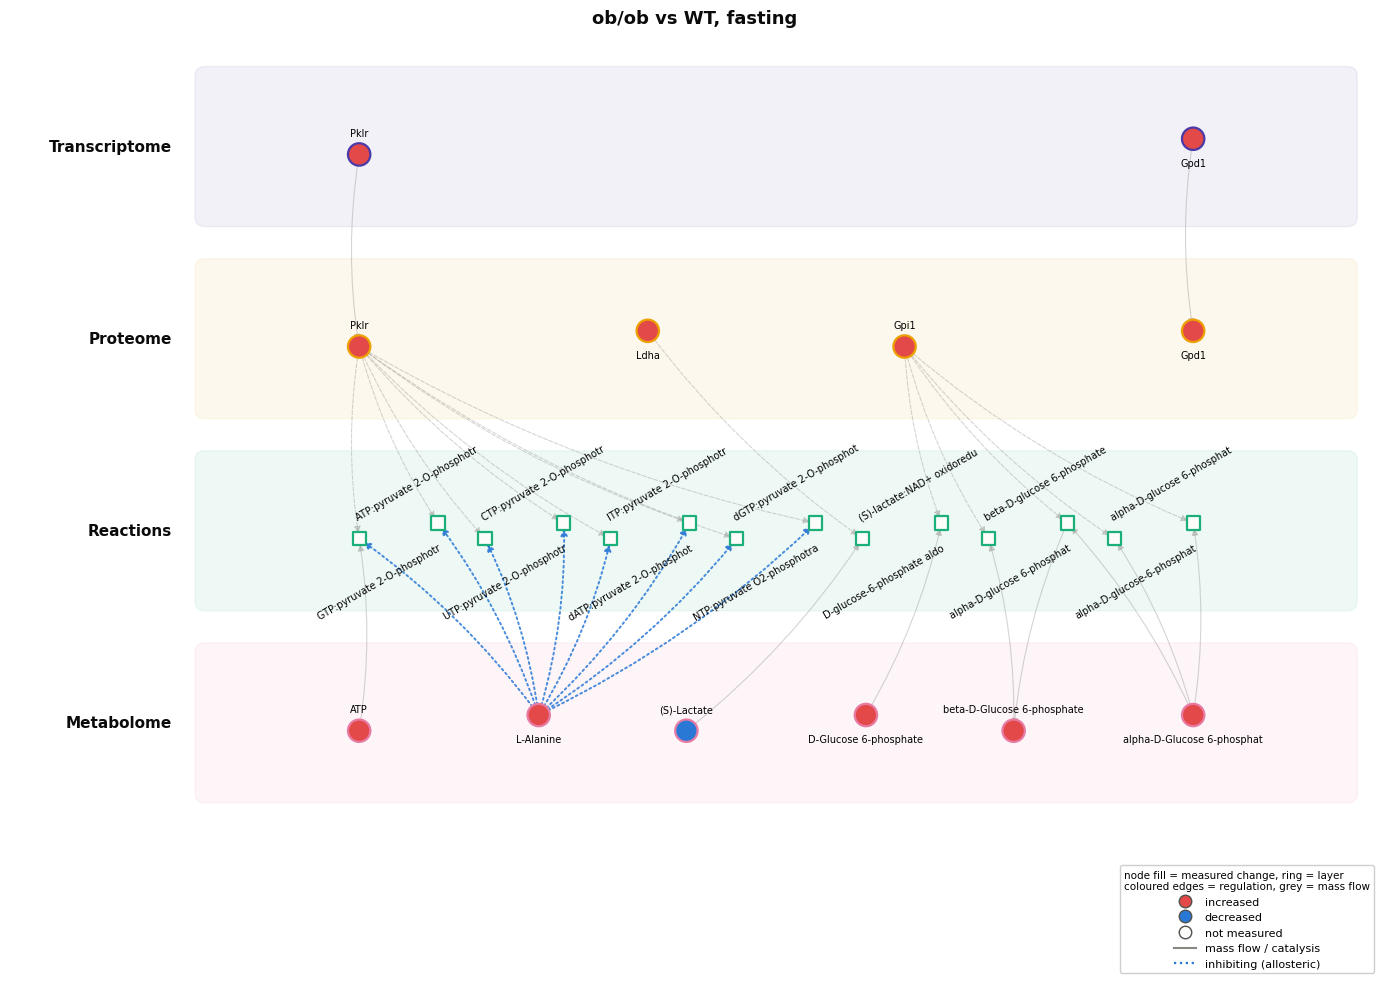

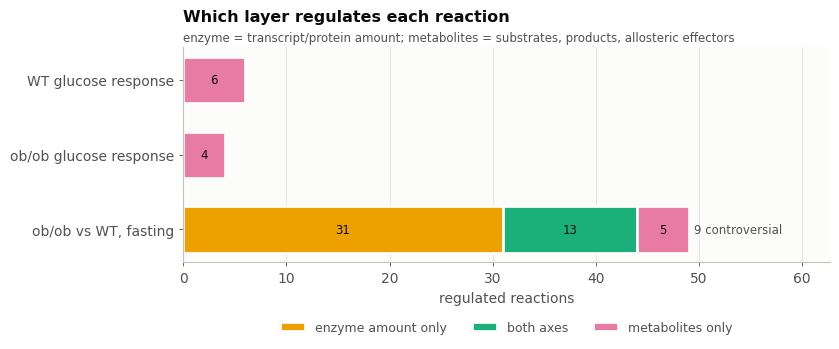

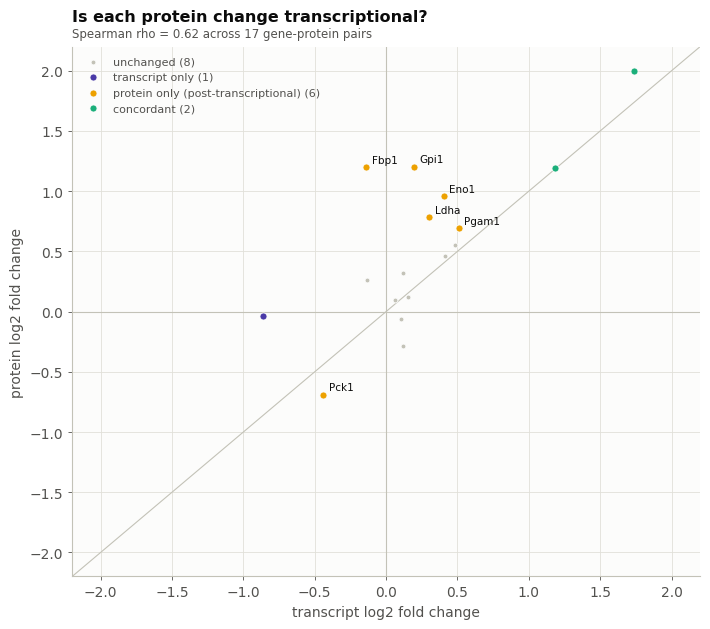

figures and tables in /Users/krv114/Documents/GitHub/transnet/data/published_results/obese_liver


In [23]:
from transnet.visualization import (
    plot_axis_composition,
    plot_expression_concordance,
    plot_transomic_network,
)

for figure, name in [
    (plot_transomic_network(responsive_subnetwork(graph), title=LABEL), "network"),
    (plot_axis_composition(composition), "axes_by_contrast"),
    (plot_expression_concordance(concordance), "concordance"),
    (paths_figure, "regulatory_paths"),
]:
    figure.savefig(OUT / f"{name}.png", dpi=150, bbox_inches="tight")
claims.to_csv(OUT / "published_claims.csv", index=False)
plt.show()
print(f"figures and tables in {OUT}")